In [1]:
import sys, os
import re
import gc
import glob
import pandas as pd
import ast
import copy
import itertools
import pickle
import joblib
import numpy as np
from pathlib import Path

In [2]:
import graphviz
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
from tqdm.notebook import tqdm

tqdm.pandas()

In [4]:
import warnings
warnings.filterwarnings('ignore')

### Loading package

In [5]:
import sys
from pathlib import Path

here_path = Path().resolve()
repo_path = here_path.parents[1]
sys.path.append(str(repo_path))

In [6]:
from py.utils import verifyDir,verifyFile

In [7]:
from py.config import Config

cfg = Config()

np.random.seed(cfg.RANDOM_STATE)
cfg.DATA_PATH, cfg.MODEL_PATH

('/media/felipe/DATA21/datasets/', '/media/felipe/DATA21/models/')

### Loading data

In [8]:
DATA_PATH=f"{cfg.DATA_PATH}crimebb/"
CSV_PATH = f"{DATA_PATH}/{cfg.YEAR}/csv/"
HF_PROCESSED = f"{DATA_PATH}/{cfg.YEAR}/csv/topics/{cfg.TOPIC_SEARCH}/"
FEATURES_PATH = f"{cfg.MODEL_PATH}crimebb/{cfg.YEAR}/creamskim/features/"
MODEL_PATH = f"{cfg.MODEL_PATH}crimebb/{cfg.YEAR}/creamskim/models/"

In [9]:
verifyDir(MODEL_PATH)

In [10]:
data2process = "tfidf" # tfidf doc2vec cbow
out_filename = "_processed" if cfg.PROCESS_TXT else ""
labels_of_interest = ["weaponization", "exploitation", "poc"]

In [11]:
%%time
# with open(f"{FEATURES_PATH}metadata{out_filename}_3_classes.pkl", 'rb') as file:
with open(f"{FEATURES_PATH}metadata{out_filename}.pkl", 'rb') as file:
    # Load the object from the file
    data_pkl = pickle.load(file)

CPU times: user 48.1 ms, sys: 26 ms, total: 74.1 ms
Wall time: 73.6 ms


In [12]:
for k in data_pkl.keys():
    if k not in ["id2word", "corpus"]:
        print(k, len(data_pkl[k]), type(data_pkl[k]), data_pkl[k].shape)

content 1050 <class 'pandas.arrays.ArrowStringArray'> (1050,)
content_processed 1050 <class 'pandas.arrays.ArrowStringArray'> (1050,)
annotations 1050 <class 'pandas.arrays.ArrowStringArray'> (1050,)
annotations_class 1050 <class 'numpy.ndarray'> (1050,)
X_tfidf 1050 <class 'numpy.ndarray'> (1050, 1773)
tfidf_names 1773 <class 'numpy.ndarray'> (1773,)
X_cbow 1050 <class 'numpy.ndarray'> (1050, 1773)
cbow_names 1773 <class 'numpy.ndarray'> (1773,)
X_doc2vec 1050 <class 'numpy.ndarray'> (1050, 5000)


In [13]:
labels_df = pd.DataFrame(data={"class": data_pkl[f"annotations_class"].copy(), "labels": data_pkl[f"annotations"].copy()})
label_map = dict(zip(labels_df["class"], labels_df["labels"]))
labels = list(label_map.values())
classes = list(label_map.keys())
labels, classes

(['poc', 'exploitation', 'weaponization', 'others', 'scam', 'warning', 'help'],
 [3, 0, 6, 2, 4, 5, 1])

In [14]:
#X = np.asarray(  df[f"X_{data2process}"].values .tolist() )
X = data_pkl[f"X_{data2process}"]
feature_names = data_pkl[f"{data2process}_names"]
# y = df["class"].values
y = data_pkl[f"annotations_class"].copy()
X.shape, y.shape, feature_names.shape

((1050, 1773), (1050,), (1773,))

### GridSearch

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold

In [16]:
# oversampling and undersampling
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

def Smote(X, y):
    sm=SMOTE(random_state=cfg.RANDOM_STATE, k_neighbors=len(np.unique(y)))
    X_over, y_over = sm.fit_resample(X, y)
    return (X_over, y_over)

def overSample(X, y):
    oversample = RandomOverSampler(random_state=cfg.RANDOM_STATE)
    X_over, y_over = oversample.fit_resample(X, y)
    return (X_over, y_over)

def underSample(X, y):
    undersample = RandomUnderSampler(random_state=cfg.RANDOM_STATE)
    X_under, y_under = undersample.fit_resample(X, y)
    return (X_under, y_under)

def one_hot_encode(categories):
    unique_categories = set(categories)
    one_hot_encoded = []

    for category in categories:
        one_hot_vector = [1 if category == unique_category else 0 for unique_category in unique_categories]
        one_hot_encoded.append(one_hot_vector)

    return one_hot_encoded

In [17]:
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.tree import plot_tree, export_graphviz

In [18]:
over_type="over"
over_train=False

In [19]:
X_train_orig, X_test, y_train_orig, y_test = train_test_split(X, y, 
                                                    stratify=y,
                                                    test_size = 0.25, 
                                                    random_state = cfg.RANDOM_STATE)

if over_type=="over":
    if over_train:
        X_train, y_train = overSample(X_train_orig, y_train_orig)
    else:
        X_over, y_over = overSample(X, y)
        X_train, _, y_train, _ = train_test_split(X_over, y_over, 
                                            stratify=y_over,
                                            test_size = 0.25, 
                                            random_state = cfg.RANDOM_STATE)
elif over_type=="under":
    if over_train:
        X_train, y_train = underSample(X_train_orig, y_train_orig)
    else:
        X_over, y_over = underSample(X, y)
        X_train, _, y_train, _ = train_test_split(X_over, y_over, 
                                            stratify=y_over,
                                            test_size = 0.25, 
                                            random_state = RANDOM_STATE)
elif over_type=="smote":
    if over_train:
        X_train, y_train = Smote(X_train_orig, y_train_orig)
    else:
        X_over, y_over = Smote(X, y)
        X_train, _, y_train, _ = train_test_split(X_over, y_over, 
                                            stratify=y_over,
                                            test_size = 0.25, 
                                            random_state = RANDOM_STATE)

else:
     X_over, y_over = X_train_orig, y_train_orig

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((2136, 1773), (263, 1773), (2136,), (263,))

In [20]:
import collections

In [21]:
indexes_ = []
min_val = min( dict( collections.Counter(y_test) ).values() )

for cur_index in np.unique(y):
    inx_ = np.where(y_test==cur_index)[0][:min_val]
    indexes_ = np.concatenate((indexes_, inx_))

X_test_balanced = X_test[indexes_.astype(int)].copy()
y_test_balanced = y_test[indexes_.astype(int)].copy()
X_test_balanced.shape, y_test_balanced.shape

((14, 1773), (14,))

In [22]:
collections.Counter(y_train), collections.Counter(y_test), collections.Counter(y_test_balanced), 

(Counter({np.int8(0): 306,
          np.int8(3): 305,
          np.int8(1): 305,
          np.int8(4): 305,
          np.int8(5): 305,
          np.int8(6): 305,
          np.int8(2): 305}),
 Counter({np.int8(6): 102,
          np.int8(3): 60,
          np.int8(2): 47,
          np.int8(0): 27,
          np.int8(5): 14,
          np.int8(1): 11,
          np.int8(4): 2}),
 Counter({np.int8(0): 2,
          np.int8(1): 2,
          np.int8(2): 2,
          np.int8(3): 2,
          np.int8(4): 2,
          np.int8(5): 2,
          np.int8(6): 2}))

### Scaler

In [23]:
from sklearn.preprocessing import StandardScaler

### Logistic Regression

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.linear_model import RidgeClassifier
from sklearn.multioutput import MultiOutputClassifier

In [25]:
lr = LogisticRegression(
    tol=1e-3,
    dual=False,  # Prefer dual=False when n_samples > n_features
    random_state=cfg.RANDOM_STATE,
    max_iter=1000,
)

parameters = {'classifier__C': np.logspace(-2, 2, num=5),
            'classifier__class_weight': [None, 'balanced'],
            'classifier__penalty': ['none', 'l2'],
           }

In [26]:
pipeline = Pipeline(
    steps = [
        ('scaler', StandardScaler()),
        # Model selecction
        ('classifier', lr),
    ],
)

In [27]:
lr_grid_search = GridSearchCV(estimator=pipeline,
                           param_grid=parameters,
                           scoring='balanced_accuracy',
                           n_jobs=5,
                           refit=True,
                           cv=StratifiedKFold(n_splits=5),  # << Use time series
                           verbose=0,
                )
lr_grid_search

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step... tol=0.001))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': array([1.e-02...e+01, 1.e+02]), 'classifier__class_weight': [None, 'balanced'], 'classifier__penalty': ['none', 'l2']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo...shuffle=False)
,"verbose verbose: intControls the verbosity: the higher, the more messages

In [28]:
%%time
clf_lr = copy.deepcopy(lr_grid_search)
clf_lr.fit(X_train, y_train)

CPU times: user 1min 4s, sys: 50.5 ms, total: 1min 4s
Wall time: 8.06 s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step... tol=0.001))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': array([1.e-02...e+01, 1.e+02]), 'classifier__class_weight': [None, 'balanced'], 'classifier__penalty': ['none', 'l2']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo...shuffle=False)
,"verbose verbose: intControls the verbosity: the higher, the more messages

In [29]:
clf_lr.best_score_, clf_lr.best_params_

(np.float64(0.8408098511747374),
 {'classifier__C': np.float64(10.0),
  'classifier__class_weight': None,
  'classifier__penalty': 'l2'})

In [30]:
y_pred = clf_lr.predict(X_test)
clf_lr_report = classification_report(y_test, y_pred, output_dict=True)

print(classification_report(y_test, y_pred, target_names=labels))

               precision    recall  f1-score   support

          poc       0.93      1.00      0.96        27
 exploitation       0.92      1.00      0.96        11
weaponization       0.83      0.94      0.88        47
       others       0.90      0.88      0.89        60
         scam       0.67      1.00      0.80         2
      warning       0.82      1.00      0.90        14
         help       0.97      0.85      0.91       102

     accuracy                           0.90       263
    macro avg       0.86      0.95      0.90       263
 weighted avg       0.91      0.90      0.91       263



In [31]:
confusion_matrix = pd.crosstab(
    [ label_map[k] for k in y_test ] ,
    [ label_map[k] for k in y_pred ] ,
    rownames=['Real'],
    colnames=['Prediction']
)
confusion_matrix

Prediction,exploitation,help,others,poc,scam,warning,weaponization
Real,,,,,,,
exploitation,27,0,0,0,0,0,0
help,0,11,0,0,0,0,0
others,0,0,44,2,0,0,1
poc,0,0,3,53,0,2,2
scam,0,0,0,0,2,0,0
warning,0,0,0,0,0,14,0
weaponization,2,1,6,4,1,1,87


#### Balanced

In [32]:
y_pred_balanced = clf_lr.predict(X_test_balanced)
print(classification_report(y_test_balanced, y_pred_balanced, target_names=labels))

               precision    recall  f1-score   support

          poc       1.00      1.00      1.00         2
 exploitation       1.00      1.00      1.00         2
weaponization       1.00      1.00      1.00         2
       others       1.00      1.00      1.00         2
         scam       1.00      1.00      1.00         2
      warning       1.00      1.00      1.00         2
         help       1.00      1.00      1.00         2

     accuracy                           1.00        14
    macro avg       1.00      1.00      1.00        14
 weighted avg       1.00      1.00      1.00        14



In [33]:
confusion_matrix = pd.crosstab(
    [ label_map[k] for k in y_test_balanced ] ,
    [ label_map[k] for k in y_pred_balanced ] ,
    rownames=['Real'],
    colnames=['Prediction']
)
confusion_matrix

Prediction,exploitation,help,others,poc,scam,warning,weaponization
Real,,,,,,,
exploitation,2,0,0,0,0,0,0
help,0,2,0,0,0,0,0
others,0,0,2,0,0,0,0
poc,0,0,0,2,0,0,0
scam,0,0,0,0,2,0,0
warning,0,0,0,0,0,2,0
weaponization,0,0,0,0,0,0,2


In [34]:
joblib.dump(clf_lr, f'{MODEL_PATH}LR_{over_type}_{round(clf_lr_report["accuracy"], 3)}.pkl')

['/media/felipe/DATA21/models/crimebb/2019/creamskim/models/LR_over_0.905.pkl']

### Rigde Regression

In [35]:
ridge = RidgeClassifier(
    tol=1e-3,
    random_state=cfg.RANDOM_STATE,
    max_iter=1000,
)

parameters = {'classifier__alpha': np.logspace(-2, 2, num=5),
               'classifier__class_weight': [None, 'balanced'],
              }

In [36]:
pipeline = Pipeline(
    steps = [
        ('scaler', StandardScaler()),
        # Model selecction
        ('classifier', ridge),
    ],
)

In [37]:
ridge_grid_search = GridSearchCV(estimator=pipeline,
                           param_grid=parameters,
                           scoring='balanced_accuracy',
                           n_jobs=5,
                           refit=True,
                           cv=StratifiedKFold(n_splits=5),  # << Use time series
                           verbose=0,
                )
ridge_grid_search

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step... tol=0.001))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__alpha': array([1.e-02...e+01, 1.e+02]), 'classifier__class_weight': [None, 'balanced']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo...shuffle=False)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for ea

In [38]:
%%time
clf_ridge = copy.deepcopy(ridge_grid_search)
clf_ridge.fit(X_train, y_train)

CPU times: user 3.2 s, sys: 42 ms, total: 3.24 s
Wall time: 3.2 s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step... tol=0.001))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__alpha': array([1.e-02...e+01, 1.e+02]), 'classifier__class_weight': [None, 'balanced']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo...shuffle=False)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for ea

In [39]:
clf_ridge.best_score_, clf_ridge.best_params_

(np.float64(0.8272418221651432),
 {'classifier__alpha': np.float64(100.0), 'classifier__class_weight': None})

In [40]:
y_pred = clf_ridge.predict(X_test)
clf_ridge_report = classification_report(y_test, y_pred, output_dict=True)

print(classification_report(y_test, y_pred, target_names=labels))

               precision    recall  f1-score   support

          poc       0.90      1.00      0.95        27
 exploitation       0.79      1.00      0.88        11
weaponization       0.88      0.96      0.92        47
       others       0.89      0.92      0.90        60
         scam       0.67      1.00      0.80         2
      warning       0.78      1.00      0.88        14
         help       0.99      0.82      0.90       102

     accuracy                           0.90       263
    macro avg       0.84      0.96      0.89       263
 weighted avg       0.92      0.90      0.90       263



In [41]:
confusion_matrix = pd.crosstab(
    [ label_map[k] for k in y_test ] ,
    [ label_map[k] for k in y_pred ] ,
    rownames=['Real'],
    colnames=['Prediction']
)
confusion_matrix

Prediction,exploitation,help,others,poc,scam,warning,weaponization
Real,,,,,,,
exploitation,27,0,0,0,0,0,0
help,0,11,0,0,0,0,0
others,0,0,45,2,0,0,0
poc,0,0,2,55,0,2,1
scam,0,0,0,0,2,0,0
warning,0,0,0,0,0,14,0
weaponization,3,3,4,5,1,2,84


#### Balanced

In [42]:
y_pred_balanced = clf_ridge.predict(X_test_balanced)
print(classification_report(y_test_balanced, y_pred_balanced, target_names=labels))

               precision    recall  f1-score   support

          poc       1.00      1.00      1.00         2
 exploitation       1.00      1.00      1.00         2
weaponization       1.00      1.00      1.00         2
       others       1.00      1.00      1.00         2
         scam       1.00      1.00      1.00         2
      warning       1.00      1.00      1.00         2
         help       1.00      1.00      1.00         2

     accuracy                           1.00        14
    macro avg       1.00      1.00      1.00        14
 weighted avg       1.00      1.00      1.00        14



In [43]:
confusion_matrix = pd.crosstab(
    [ label_map[k] for k in y_test_balanced ] ,
    [ label_map[k] for k in y_pred_balanced ] ,
    rownames=['Real'],
    colnames=['Prediction']
)
confusion_matrix

Prediction,exploitation,help,others,poc,scam,warning,weaponization
Real,,,,,,,
exploitation,2,0,0,0,0,0,0
help,0,2,0,0,0,0,0
others,0,0,2,0,0,0,0
poc,0,0,0,2,0,0,0
scam,0,0,0,0,2,0,0
warning,0,0,0,0,0,2,0
weaponization,0,0,0,0,0,0,2


In [44]:
joblib.dump(clf_ridge, f'{MODEL_PATH}Ridge_{over_type}_{round(clf_ridge_report["accuracy"], 3)}.pkl')

['/media/felipe/DATA21/models/crimebb/2019/creamskim/models/Ridge_over_0.905.pkl']

### LinearSVC

In [45]:
linear_svc = LinearSVC(
    tol=1e-3,
    random_state=cfg.RANDOM_STATE,
    max_iter=1000,
)


parameters = {'classifier__C': np.logspace(-2, 2, num=5),
              'classifier__class_weight': [None, 'balanced'],
              'classifier__penalty': ['l2'],
              'classifier__loss': ['hinge', 'squared_hinge'],
               }

In [46]:
pipeline = Pipeline(
    steps = [
        ('scaler', StandardScaler()),
        # Model selecction
        ('classifier', linear_svc),
    ],
)

In [47]:
lsvc_grid_search = GridSearchCV(estimator=pipeline,
                           param_grid=parameters,
                           scoring='balanced_accuracy',
                           n_jobs=5,
                           refit=True,
                           cv=StratifiedKFold(n_splits=5),  # << Use time series
                           verbose=0,
                    )
lsvc_grid_search

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step... tol=0.001))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': array([1.e-02...e+01, 1.e+02]), 'classifier__class_weight': [None, 'balanced'], 'classifier__loss': ['hinge', 'squared_hinge'], 'classifier__penalty': ['l2']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo...shuffle=False)
,"verbose verbose: intControls the 

In [48]:
%%time
clf_lsvc = copy.deepcopy(lsvc_grid_search)
clf_lsvc.fit(X_train, y_train)

CPU times: user 36.5 s, sys: 427 ms, total: 36.9 s
Wall time: 6min 20s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step... tol=0.001))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': array([1.e-02...e+01, 1.e+02]), 'classifier__class_weight': [None, 'balanced'], 'classifier__loss': ['hinge', 'squared_hinge'], 'classifier__penalty': ['l2']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo...shuffle=False)
,"verbose verbose: intControls the 

In [49]:
clf_lsvc.best_score_, clf_lsvc.best_params_

(np.float64(0.8291002493012012),
 {'classifier__C': np.float64(0.01),
  'classifier__class_weight': None,
  'classifier__loss': 'squared_hinge',
  'classifier__penalty': 'l2'})

In [50]:
y_pred = clf_lsvc.predict(X_test)
clf_lsvc_report = classification_report(y_test, y_pred, output_dict=True)

print(classification_report(y_test, y_pred, target_names=labels))

               precision    recall  f1-score   support

          poc       0.93      1.00      0.96        27
 exploitation       0.79      1.00      0.88        11
weaponization       0.85      0.98      0.91        47
       others       0.93      0.92      0.92        60
         scam       0.50      1.00      0.67         2
      warning       0.78      1.00      0.88        14
         help       0.99      0.82      0.90       102

     accuracy                           0.91       263
    macro avg       0.82      0.96      0.87       263
 weighted avg       0.92      0.91      0.91       263



In [51]:
confusion_matrix = pd.crosstab(
    [ label_map[k] for k in y_test ] ,
    [ label_map[k] for k in y_pred ] ,
    rownames=['Real'],
    colnames=['Prediction']
)
confusion_matrix

Prediction,exploitation,help,others,poc,scam,warning,weaponization
Real,,,,,,,
exploitation,27,0,0,0,0,0,0
help,0,11,0,0,0,0,0
others,0,0,46,0,0,0,1
poc,0,0,2,55,1,2,0
scam,0,0,0,0,2,0,0
warning,0,0,0,0,0,14,0
weaponization,2,3,6,4,1,2,84


#### Balanced

In [52]:
y_pred_balanced = clf_lsvc.predict(X_test_balanced)
print(classification_report(y_test_balanced, y_pred_balanced, target_names=labels))

               precision    recall  f1-score   support

          poc       1.00      1.00      1.00         2
 exploitation       1.00      1.00      1.00         2
weaponization       1.00      1.00      1.00         2
       others       1.00      1.00      1.00         2
         scam       1.00      1.00      1.00         2
      warning       1.00      1.00      1.00         2
         help       1.00      1.00      1.00         2

     accuracy                           1.00        14
    macro avg       1.00      1.00      1.00        14
 weighted avg       1.00      1.00      1.00        14



In [53]:
confusion_matrix = pd.crosstab(
    [ label_map[k] for k in y_test_balanced ] ,
    [ label_map[k] for k in y_pred_balanced ] ,
    rownames=['Real'],
    colnames=['Prediction']
)
confusion_matrix

Prediction,exploitation,help,others,poc,scam,warning,weaponization
Real,,,,,,,
exploitation,2,0,0,0,0,0,0
help,0,2,0,0,0,0,0
others,0,0,2,0,0,0,0
poc,0,0,0,2,0,0,0
scam,0,0,0,0,2,0,0
warning,0,0,0,0,0,2,0
weaponization,0,0,0,0,0,0,2


In [54]:
joblib.dump(clf_lsvc, f'{MODEL_PATH}LSVC_{over_type}_{round(clf_lsvc_report["accuracy"], 3)}.pkl')

['/media/felipe/DATA21/models/crimebb/2019/creamskim/models/LSVC_over_0.909.pkl']

### SVC

In [55]:
svm = SVC(
    tol=1e-3,
    random_state=cfg.RANDOM_STATE,
    max_iter=1000,
)

parameters = {'classifier__C': np.logspace(-2, 2, num=5),
             'classifier__class_weight': [None, 'balanced'],
             'classifier__gamma': ['scale', 'auto', 1, 0.1, 0.01, 0.001, 0.0001],
             'classifier__kernel': ['linear', 'rbf']
            }

In [56]:
pipeline = Pipeline(
    steps = [
        ('scaler', StandardScaler()),
        # Model selecction
        ('classifier', svm),
    ],
)

In [57]:
svm_grid_search = GridSearchCV(estimator=pipeline,
                           param_grid=parameters,
                           scoring='balanced_accuracy',
                           n_jobs=5,
                           refit=True,
                           cv=StratifiedKFold(n_splits=5),  # << Use time series
                           verbose=0,
                    )
svm_grid_search

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': array([1.e-02...e+01, 1.e+02]), 'classifier__class_weight': [None, 'balanced'], 'classifier__gamma': ['scale', 'auto', ...], 'classifier__kernel': ['linear', 'rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo...shuffle=False)
,"verbose verbose: intContro

In [58]:
%%time
clf_svm = copy.deepcopy(svm_grid_search)
clf_svm.fit(X_train, y_train)

CPU times: user 2.44 s, sys: 386 ms, total: 2.83 s
Wall time: 4min 39s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': array([1.e-02...e+01, 1.e+02]), 'classifier__class_weight': [None, 'balanced'], 'classifier__gamma': ['scale', 'auto', ...], 'classifier__kernel': ['linear', 'rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo...shuffle=False)
,"verbose verbose: intContro

In [59]:
clf_svm.best_score_, clf_svm.best_params_

(np.float64(0.867522852610108),
 {'classifier__C': np.float64(10.0),
  'classifier__class_weight': None,
  'classifier__gamma': 'scale',
  'classifier__kernel': 'rbf'})

In [60]:
y_pred = clf_svm.predict(X_test)
clf_svm_report = classification_report(y_test, y_pred, output_dict=True)

print(classification_report(y_test, y_pred, target_names=labels))

               precision    recall  f1-score   support

          poc       1.00      1.00      1.00        27
 exploitation       0.85      1.00      0.92        11
weaponization       0.98      0.96      0.97        47
       others       0.96      0.90      0.93        60
         scam       1.00      1.00      1.00         2
      warning       0.93      1.00      0.97        14
         help       0.93      0.95      0.94       102

     accuracy                           0.95       263
    macro avg       0.95      0.97      0.96       263
 weighted avg       0.95      0.95      0.95       263



In [61]:
confusion_matrix = pd.crosstab(
    [ label_map[k] for k in y_test ] ,
    [ label_map[k] for k in y_pred ] ,
    rownames=['Real'],
    colnames=['Prediction']
)
confusion_matrix

Prediction,exploitation,help,others,poc,scam,warning,weaponization
Real,,,,,,,
exploitation,27,0,0,0,0,0,0
help,0,11,0,0,0,0,0
others,0,0,45,0,0,0,2
poc,0,0,0,54,0,1,5
scam,0,0,0,0,2,0,0
warning,0,0,0,0,0,14,0
weaponization,0,2,1,2,0,0,97


#### Balanced

In [62]:
y_pred_balanced = clf_svm.predict(X_test_balanced)
print(classification_report(y_test_balanced, y_pred_balanced, target_names=labels))

               precision    recall  f1-score   support

          poc       1.00      1.00      1.00         2
 exploitation       1.00      1.00      1.00         2
weaponization       1.00      1.00      1.00         2
       others       1.00      1.00      1.00         2
         scam       1.00      1.00      1.00         2
      warning       1.00      1.00      1.00         2
         help       1.00      1.00      1.00         2

     accuracy                           1.00        14
    macro avg       1.00      1.00      1.00        14
 weighted avg       1.00      1.00      1.00        14



In [63]:
confusion_matrix = pd.crosstab(
    [ label_map[k] for k in y_test_balanced ] ,
    [ label_map[k] for k in y_pred_balanced ] ,
    rownames=['Real'],
    colnames=['Prediction']
)
confusion_matrix

Prediction,exploitation,help,others,poc,scam,warning,weaponization
Real,,,,,,,
exploitation,2,0,0,0,0,0,0
help,0,2,0,0,0,0,0
others,0,0,2,0,0,0,0
poc,0,0,0,2,0,0,0
scam,0,0,0,0,2,0,0
warning,0,0,0,0,0,2,0
weaponization,0,0,0,0,0,0,2


In [64]:
joblib.dump(clf_svm, f'{MODEL_PATH}SVM_{over_type}_{round(clf_svm_report["accuracy"], 3)}.pkl')

['/media/felipe/DATA21/models/crimebb/2019/creamskim/models/SVM_over_0.951.pkl']

### DecisionTree

In [65]:
from sklearn.tree import DecisionTreeClassifier

In [66]:
d_tree = DecisionTreeClassifier(random_state=cfg.RANDOM_STATE)

In [67]:
pipeline = Pipeline(
    steps = [
        ('scaler', StandardScaler()),
        # 3. Model selecction
        ('classifier', d_tree),
    ],
)

In [68]:
parameters = {'classifier__max_features': [None, 'sqrt'],
              'classifier__max_depth': np.append(None, np.arange(10, 110, 10) ), 
              'classifier__min_samples_split': np.arange(3, 7), 
              'classifier__min_samples_leaf':np.arange(3, 7), 
             }

In [69]:
dt_grid_search = GridSearchCV(estimator=pipeline,
                           param_grid=parameters,
                           scoring='balanced_accuracy',
                           n_jobs=5,
                           refit=True,
                           cv=StratifiedKFold(n_splits=5),  # << Use time series
                           verbose=0,
                    )
dt_grid_search

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_depth': array([None, ... dtype=object), 'classifier__max_features': [None, 'sqrt'], 'classifier__min_samples_leaf': array([3, 4, 5, 6]), 'classifier__min_samples_split': array([3, 4, 5, 6])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo...shuffle=False)
,"v

In [70]:
%%time
clf_dt = copy.deepcopy(dt_grid_search)
clf_dt.fit(X_train, y_train)

CPU times: user 1.23 s, sys: 146 ms, total: 1.37 s
Wall time: 52.6 s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_depth': array([None, ... dtype=object), 'classifier__max_features': [None, 'sqrt'], 'classifier__min_samples_leaf': array([3, 4, 5, 6]), 'classifier__min_samples_split': array([3, 4, 5, 6])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo...shuffle=False)
,"v

In [71]:
clf_dt.best_score_, clf_dt.best_params_

(np.float64(0.7527536450857444),
 {'classifier__max_depth': None,
  'classifier__max_features': None,
  'classifier__min_samples_leaf': np.int64(3),
  'classifier__min_samples_split': np.int64(3)})

In [72]:
y_pred = clf_dt.predict(X_test)
clf_dt_report = classification_report(y_test, y_pred, output_dict=True)

print(classification_report(y_test, y_pred, target_names=labels))

               precision    recall  f1-score   support

          poc       0.75      1.00      0.86        27
 exploitation       0.61      1.00      0.76        11
weaponization       0.68      0.72      0.70        47
       others       0.79      0.70      0.74        60
         scam       0.50      1.00      0.67         2
      warning       0.87      0.93      0.90        14
         help       0.90      0.76      0.83       102

     accuracy                           0.79       263
    macro avg       0.73      0.87      0.78       263
 weighted avg       0.80      0.79      0.79       263



In [73]:
confusion_matrix = pd.crosstab(
    [ label_map[k] for k in y_test ] ,
    [ label_map[k] for k in y_pred ] ,
    rownames=['Real'],
    colnames=['Prediction']
)
confusion_matrix

Prediction,exploitation,help,others,poc,scam,warning,weaponization
Real,,,,,,,
exploitation,27,0,0,0,0,0,0
help,0,11,0,0,0,0,0
others,4,3,34,3,0,0,3
poc,2,1,6,42,1,2,6
scam,0,0,0,0,2,0,0
warning,0,0,1,0,0,13,0
weaponization,3,3,9,8,1,0,78


#### Balanced

In [74]:
y_pred_balanced = clf_dt.predict(X_test_balanced)
print(classification_report(y_test_balanced, y_pred_balanced, target_names=labels))

               precision    recall  f1-score   support

          poc       1.00      1.00      1.00         2
 exploitation       1.00      1.00      1.00         2
weaponization       1.00      1.00      1.00         2
       others       0.67      1.00      0.80         2
         scam       1.00      1.00      1.00         2
      warning       1.00      1.00      1.00         2
         help       1.00      0.50      0.67         2

     accuracy                           0.93        14
    macro avg       0.95      0.93      0.92        14
 weighted avg       0.95      0.93      0.92        14



In [75]:
confusion_matrix = pd.crosstab(
    [ label_map[k] for k in y_test_balanced ] ,
    [ label_map[k] for k in y_pred_balanced ] ,
    rownames=['Real'],
    colnames=['Prediction']
)
confusion_matrix

Prediction,exploitation,help,others,poc,scam,warning,weaponization
Real,,,,,,,
exploitation,2,0,0,0,0,0,0
help,0,2,0,0,0,0,0
others,0,0,2,0,0,0,0
poc,0,0,0,2,0,0,0
scam,0,0,0,0,2,0,0
warning,0,0,0,0,0,2,0
weaponization,0,0,0,1,0,0,1


In [76]:
joblib.dump(clf_dt, f'{MODEL_PATH}DT_{over_type}_{round(clf_dt_report["accuracy"], 3)}.pkl')

['/media/felipe/DATA21/models/crimebb/2019/creamskim/models/DT_over_0.787.pkl']

#### Plot Tree

In [77]:
dot_data = export_graphviz(clf_dt.best_estimator_[1], out_file=None, 
                          feature_names=feature_names,  
                          class_names=labels,  
                          filled=True, rounded=True,
                          #max_depth=4,
                          special_characters=True)  

In [78]:
graph = graphviz.Source(dot_data)
graph.render(f'{MODEL_PATH}DT_{over_type}_{round(clf_dt_report["accuracy"], 3)}')

'/media/felipe/DATA21/models/crimebb/2019/creamskim/models/DT_over_0.787.pdf'

In [79]:
graph = graphviz.Source(dot_data, format="png")
graph.render(f'{MODEL_PATH}DT_{over_type}_{round(clf_dt_report["accuracy"], 3)}')

'/media/felipe/DATA21/models/crimebb/2019/creamskim/models/DT_over_0.787.png'

### RandomForest

In [80]:
from sklearn.ensemble import RandomForestClassifier

In [81]:
r_forest = RandomForestClassifier(random_state=cfg.RANDOM_STATE, n_estimators=600)

In [82]:
pipeline = Pipeline(
    steps = [
        ('scaler', StandardScaler()),
        # 3. Model selecction
        ('classifier', r_forest),
    ],
)

In [83]:
parameters = {#'classifier__n_estimators': np.arange(200, 1200, 100),
              'classifier__bootstrap': [True, False],
              # Tree parameters
              'classifier__max_features': [None, 'sqrt'],
              'classifier__max_depth': np.append(None, np.arange(10, 80, 10) ),
              'classifier__min_samples_split': np.arange(3, 5),
              'classifier__min_samples_leaf':np.arange(3, 5),
             }

In [84]:
parameters = {#'classifier__n_estimators': np.arange(200, 1200, 100),
              'classifier__bootstrap': [False],
              # Tree parameters
              'classifier__max_features': ['sqrt'],
              'classifier__max_depth': [70],
              'classifier__min_samples_split': [3],
              'classifier__min_samples_leaf': [3],
             }

In [85]:
rf_grid_search = GridSearchCV(estimator=pipeline,
                           param_grid=parameters,
                           scoring='balanced_accuracy',
                           n_jobs=5,
                           refit=True,
                           cv=StratifiedKFold(n_splits=5),  # << Use time series
                           verbose=0,
                )
rf_grid_search

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__bootstrap': [False], 'classifier__max_depth': [70], 'classifier__max_features': ['sqrt'], 'classifier__min_samples_leaf': [3], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo...shuffle=False)
,"verbose verbose: intControls the verbosity: the higher, the more

In [86]:
%%time
clf_rf = copy.deepcopy(rf_grid_search)
clf_rf.fit(X_train, y_train)

CPU times: user 4.32 s, sys: 30.9 ms, total: 4.35 s
Wall time: 10.7 s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__bootstrap': [False], 'classifier__max_depth': [70], 'classifier__max_features': ['sqrt'], 'classifier__min_samples_leaf': [3], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo...shuffle=False)
,"verbose verbose: intControls the verbosity: the higher, the more

In [87]:
clf_rf.best_score_, clf_rf.best_params_

(np.float64(0.851582684898391),
 {'classifier__bootstrap': False,
  'classifier__max_depth': 70,
  'classifier__max_features': 'sqrt',
  'classifier__min_samples_leaf': 3,
  'classifier__min_samples_split': 3})

In [88]:
y_pred = clf_rf.predict(X_test)
clf_rf_report = classification_report(y_test, y_pred, output_dict=True)

print(classification_report(y_test, y_pred, target_names=labels))

               precision    recall  f1-score   support

          poc       0.96      1.00      0.98        27
 exploitation       0.92      1.00      0.96        11
weaponization       0.90      0.98      0.94        47
       others       0.95      0.90      0.92        60
         scam       1.00      1.00      1.00         2
      warning       0.93      0.93      0.93        14
         help       0.96      0.93      0.95       102

     accuracy                           0.94       263
    macro avg       0.95      0.96      0.95       263
 weighted avg       0.94      0.94      0.94       263



In [89]:
confusion_matrix = pd.crosstab(
    [ label_map[k] for k in y_test ] ,
    [ label_map[k] for k in y_pred ] ,
    rownames=['Real'],
    colnames=['Prediction']
)
confusion_matrix

Prediction,exploitation,help,others,poc,scam,warning,weaponization
Real,,,,,,,
exploitation,27,0,0,0,0,0,0
help,0,11,0,0,0,0,0
others,0,0,46,1,0,0,0
poc,0,0,1,54,0,1,4
scam,0,0,0,0,2,0,0
warning,0,0,1,0,0,13,0
weaponization,1,1,3,2,0,0,95


#### Balanced

In [90]:
y_pred_balanced = clf_rf.predict(X_test_balanced)
print(classification_report(y_test_balanced, y_pred_balanced, target_names=labels))

               precision    recall  f1-score   support

          poc       1.00      1.00      1.00         2
 exploitation       1.00      1.00      1.00         2
weaponization       1.00      1.00      1.00         2
       others       1.00      1.00      1.00         2
         scam       1.00      1.00      1.00         2
      warning       1.00      1.00      1.00         2
         help       1.00      1.00      1.00         2

     accuracy                           1.00        14
    macro avg       1.00      1.00      1.00        14
 weighted avg       1.00      1.00      1.00        14



In [91]:
confusion_matrix = pd.crosstab(
    [ label_map[k] for k in y_test_balanced ] ,
    [ label_map[k] for k in y_pred_balanced ] ,
    rownames=['Real'],
    colnames=['Prediction']
)
confusion_matrix

Prediction,exploitation,help,others,poc,scam,warning,weaponization
Real,,,,,,,
exploitation,2,0,0,0,0,0,0
help,0,2,0,0,0,0,0
others,0,0,2,0,0,0,0
poc,0,0,0,2,0,0,0
scam,0,0,0,0,2,0,0
warning,0,0,0,0,0,2,0
weaponization,0,0,0,0,0,0,2


In [92]:
joblib.dump(clf_rf, f'{MODEL_PATH}RF_{over_type}_{round(clf_rf_report["accuracy"], 3)}.pkl')

['/media/felipe/DATA21/models/crimebb/2019/creamskim/models/RF_over_0.943.pkl']

#### Feature Importance

In [93]:
importances = clf_rf.best_estimator_[1].feature_importances_
std = np.std([tree.feature_importances_ for tree in clf_rf.best_estimator_[1].estimators_], axis=0)

In [94]:
forest_importances = pd.Series(importances, index=feature_names)
forest_importances.sort_values(ascending=False, inplace=True)
forest_importances_df = forest_importances.to_frame()
forest_importances_df.reset_index(inplace=True)
forest_importances

cve        0.014859
exploit    0.011982
fud        0.011563
help       0.009399
want       0.008000
             ...   
obj        0.000000
botnets    0.000000
vbs        0.000000
shown      0.000000
shot       0.000000
Length: 1773, dtype: float64

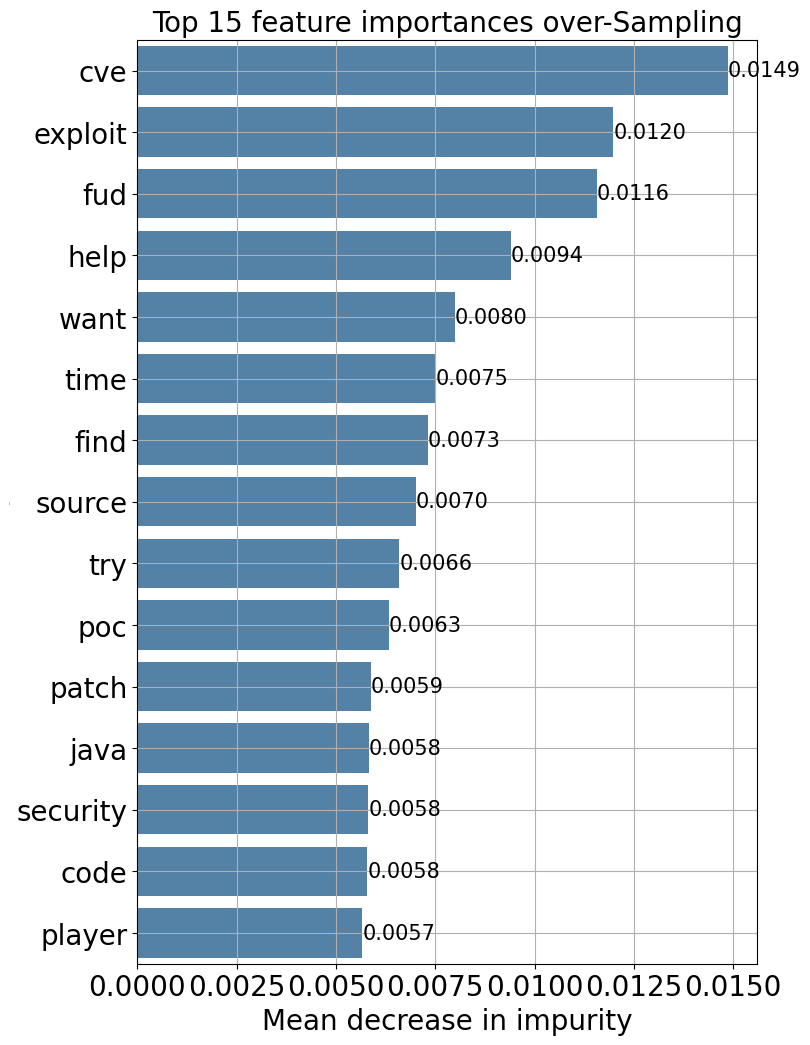

In [95]:
_, ax = plt.subplots(figsize=(8,12), nrows=1, ncols=1, sharex=False, sharey=False)

sns_fig = sns.barplot(
            data=forest_importances_df.iloc[:cfg.TOP_K_FEATURES],
            x=forest_importances_df.iloc[:cfg.TOP_K_FEATURES].columns[1],
            y=forest_importances_df.iloc[:cfg.TOP_K_FEATURES].columns[0],
            orient="h",
            ax=ax,
            color="steelblue",
            #order=estado_df.sort_values(estado_df.columns[1], ascending=False)[estado_df.columns[0]]
           )

sns_fig.set_title(f"Top {cfg.TOP_K_FEATURES} feature importances {over_type}-Sampling", fontsize=20)
sns_fig.set_ylabel(f"Label", fontsize=0)
sns_fig.set_xlabel('Mean decrease in impurity', fontsize=20)

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='x', rotation=0, labelsize=20)

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='y', labelsize=20)

# add annotation
_ = sns_fig.bar_label(sns_fig.containers[0], fmt='%.4f', fontsize=15,rotation=0)
ax.grid(True)
# add a space on y for the annotations
#sns_fig.margins(x=0.1)
# plt.savefig(f'{MODEL_PATH}RF_{label_to_focus}_{over_type}_feature_importance_{round(clf_rf_report["accuracy"], 3)}.png')

### SHAP

In [96]:
import shap
shap.initjs()

In [97]:
# explainer = shap.TreeExplainer(clf_rf.best_estimator_[1])
shap_explainer = shap.Explainer(clf_rf.best_estimator_[1], X_train)

#### Test

In [98]:
X_test.shape

(263, 1773)

In [99]:
%%time
#shap_values = explainer.shap_values(X_test,  y_test)#, check_additivity=False)
shap_values_test = shap_explainer.shap_values(X_test)
shap_values_test.shape

 98%|===================| 1811/1841 [00:53<00:00]        

CPU times: user 53.3 s, sys: 192 ms, total: 53.5 s
Wall time: 53.2 s


(263, 1773, 7)

In [100]:
shap_values_instance_narray =  np.mean(np.array(shap_values_test), axis=2)
shap_values_df = pd.DataFrame(shap_values_instance_narray, columns=feature_names).abs()
#shap_values_df.index = [ label_map[idx] for idx in list(shap_values_df.index) ]
shap_values_melt_df = pd.melt(shap_values_df.T.reset_index(), id_vars="index", var_name="label", value_name="value")
mean_shap_values_df = shap_values_df.abs().sum().sort_values(ascending=False).reset_index()
top_k_features_names = mean_shap_values_df["index"][:15].values.tolist()
sort_df = mean_shap_values_df[ mean_shap_values_df["index"].isin(top_k_features_names) ]
sort_df['index'] = pd.Categorical(sort_df['index'], categories=top_k_features_names, ordered=True)
sort_df.rename(columns={0: "value", "index": "label"}, inplace=True)
sort_df

,label,value
0,cve,1.121123e-08
1,exploit,6.994891e-09
2,fud,1.374350e-09
3,exe,1.356383e-09
4,code,1.274798e-09
5,arbitrary,1.226015e-09
6,site,1.157989e-09
7,vulnerable,9.286292e-10
8,want,8.868405e-10
9,find,8.224736e-10


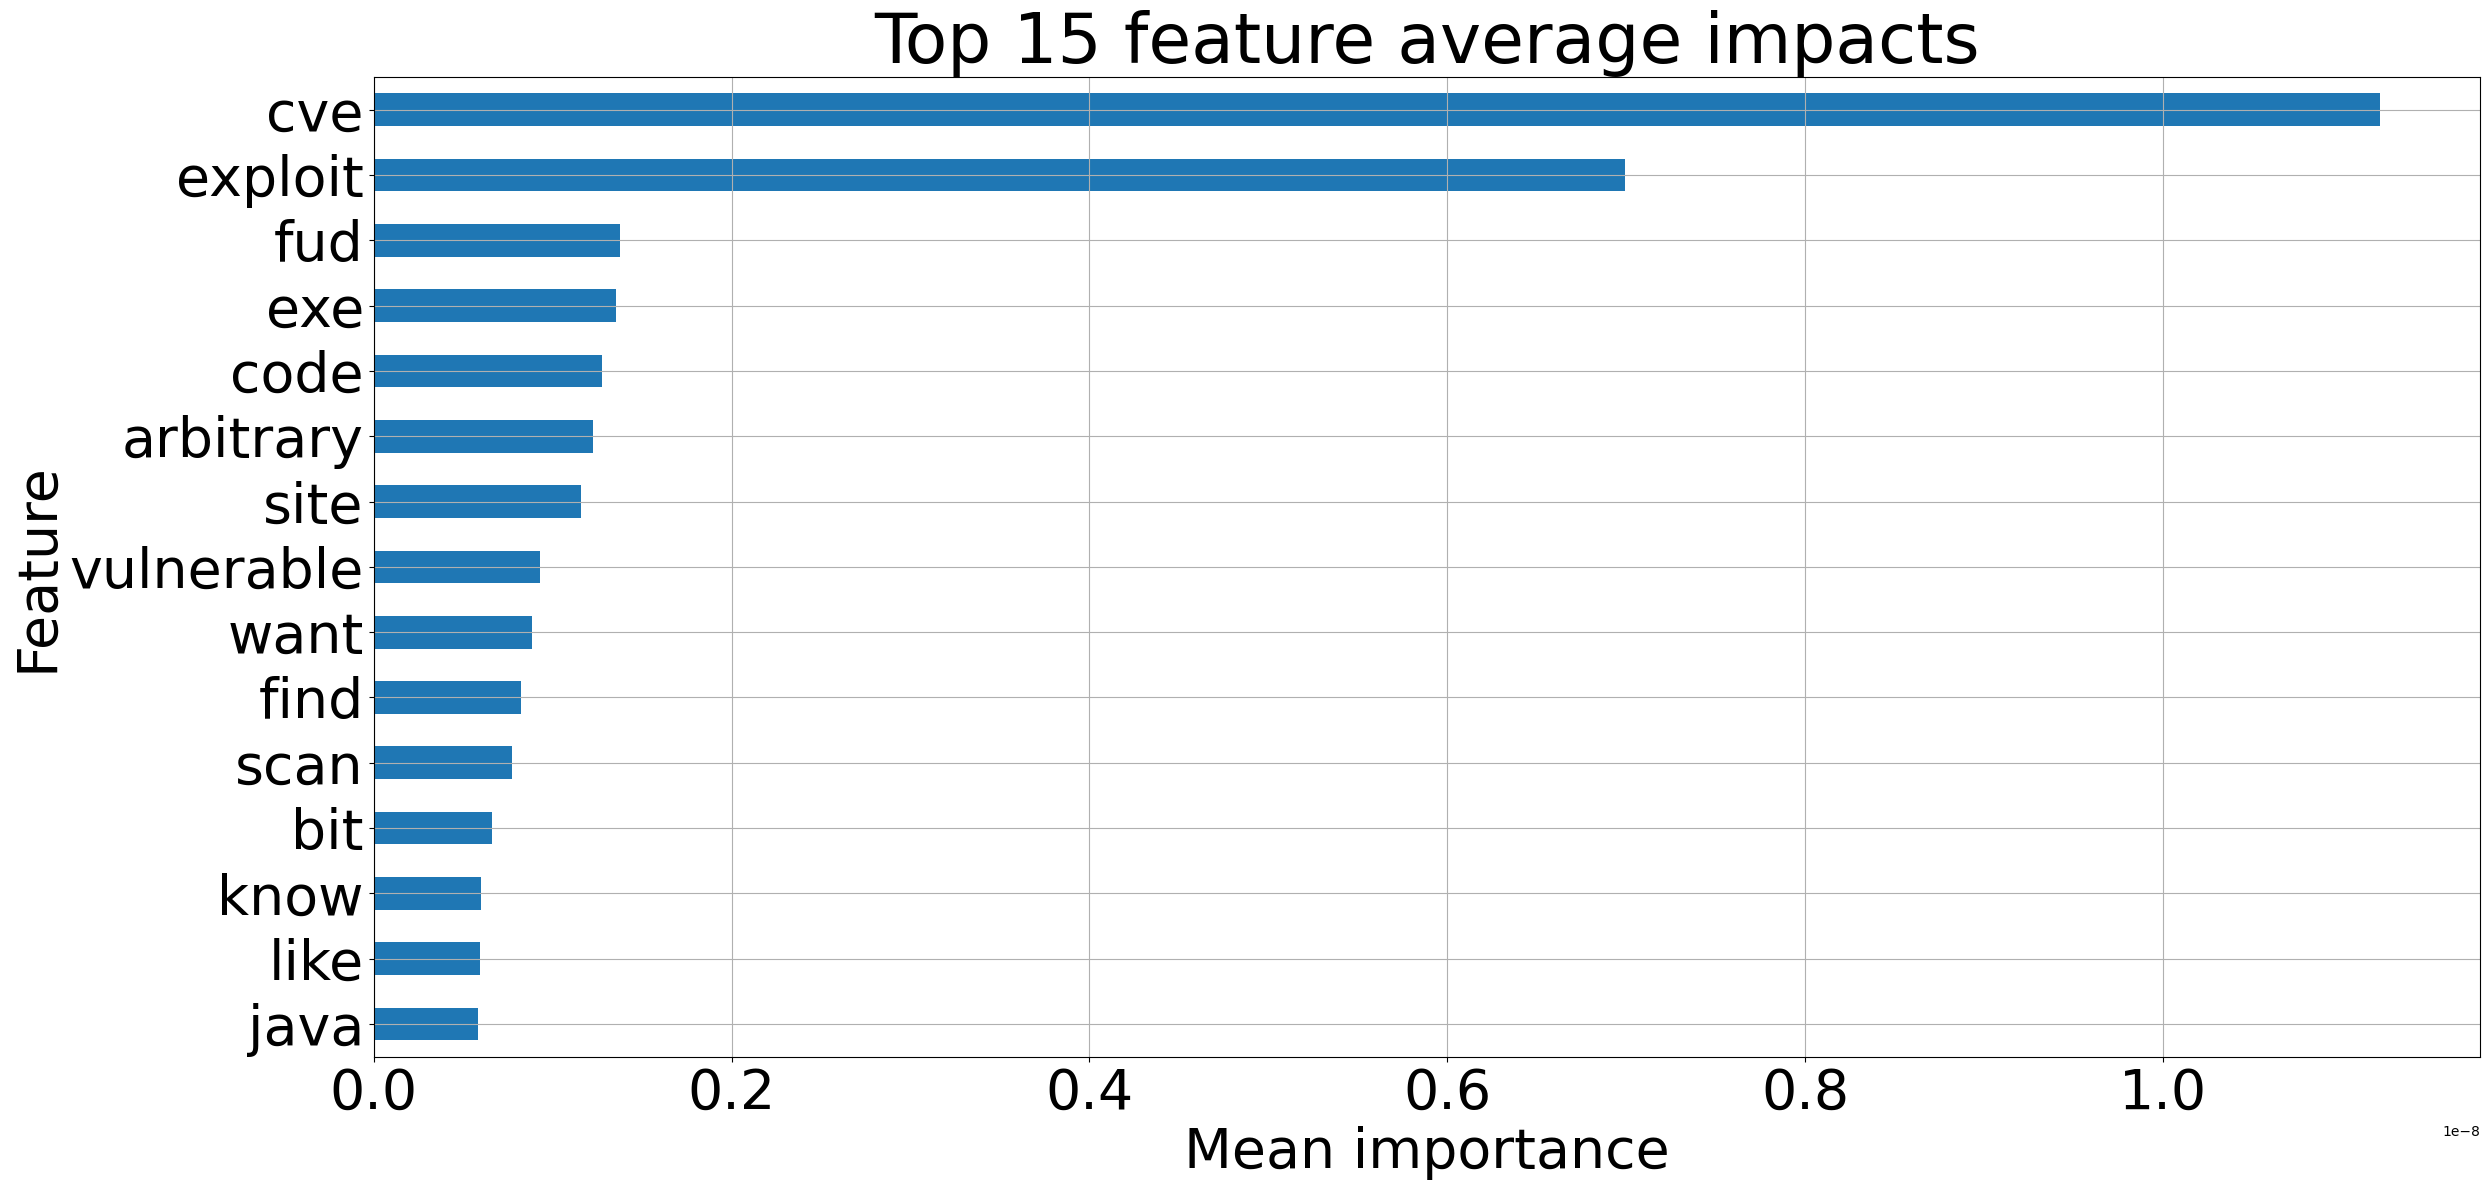

In [101]:
_, ax = plt.subplots(figsize=(25, 12))

sort_df.sort_values("value").plot(
    kind="barh",
    x="label",
    y="value",
    legend=False,
    ax=ax
)

ax.set_title(
    f"Top {cfg.TOP_K_FEATURES} feature average impacts",
    fontsize=50
)

ax.set_xlabel("Mean importance", fontsize=40)
ax.set_ylabel("Feature", fontsize=40)

ax.tick_params(axis="x", labelsize=40)
ax.tick_params(axis="y", labelsize=40)

ax.grid(True)

plt.tight_layout()